## Install libraries and packages

In [1]:
#Install packages into kernel's enviornment
%pip install seaborn scikit-learn
%pip install -e '../../decipher-bc'


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Obtaining file:///Users/alanxie/CodingProjects/Columbia/Azizi%20Lab/Spatial%20Nut%20Carcinoma/decipher-bc
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for scdecipher (pyproject.toml) ... done
  Created wheel for scdecipher: filename=scdecipher-0.1.3-py3-none-any.whl size=2193 sha256=a083d111b7757fd42c95b1c711ba62e2d1ae21b110921676f57fa3e48194b60f
  Stored in directory: /private/var/folders/3p/7nndjfj95j1b_fk0h38c9_y80000gn/T/pip-ephem-wheel-cache-jf21m1v6/wheels/ea/06/26/26159dbfb6aa8149e61b1400ecea7c99526e36bf7872679e1e
Successfully built scdecipher
  Attempting uninstall: scdecipher
    Found existing installation: scdecipher 0.

In [2]:
#Import libraries and packages
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import scanpy as sc 
#print(matplotlib.__version__)
import IPython
#print(IPython.__version__)
import logging

In [3]:
# Automatically reload the package if you edit the .py files
%load_ext autoreload
%autoreload 2

import warnings; warnings.filterwarnings("ignore") # remove scanpy warnings for the tutorial.

In [4]:
# Import the new package name
import decipher as dc
dc.pl.activate_journal_quality()

In [5]:
# Import batch corection models
import sys
sys.path.insert(0, '..')   # adds decipher-bc-methods/ to path

import importlib
avzx = importlib.import_module('attention-v-z-x')   # avzx.tl.decipher_train(...)
cvtz = importlib.import_module('concat-v-to-z')     # cvtz.tl.decipher_train(...)

## Load data

In [6]:
adata = sc.read_h5ad('../Data/Simulated Data/Simulated Adata/v-to-z/v_to_z_0.20_0.40_0.60.h5ad')
adata.uns["color_palette"] = None
color_palette = None

## Run native decipher on simulated data

Epoch 248 (batch 20/20) | | train elbo: 98.17 (last epoch: 97.30) | val ll: 109.00:  25%|██▍       | 248/1000 [00:41<02:04,  6.05it/s]2026-06-15 16:29:06,756 | INFO : Early stopping has been triggered.
2026-06-15 16:29:06,758 | INFO : Added `.obsm['decipher_v']`: the Decipher v space.
2026-06-15 16:29:06,758 | INFO : Added `.obsm['decipher_z']`: the Decipher z space.
2026-06-15 16:29:06,761 | INFO : Saving decipher model with run_id 2026-06-15-16-29-06-rectilinear-purple-syrup.


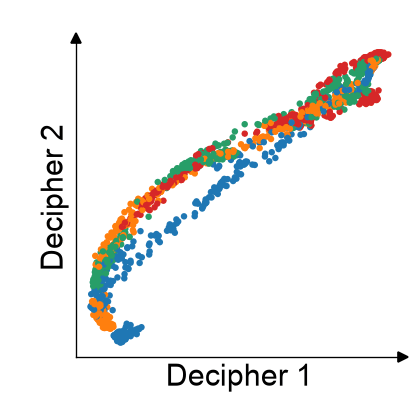

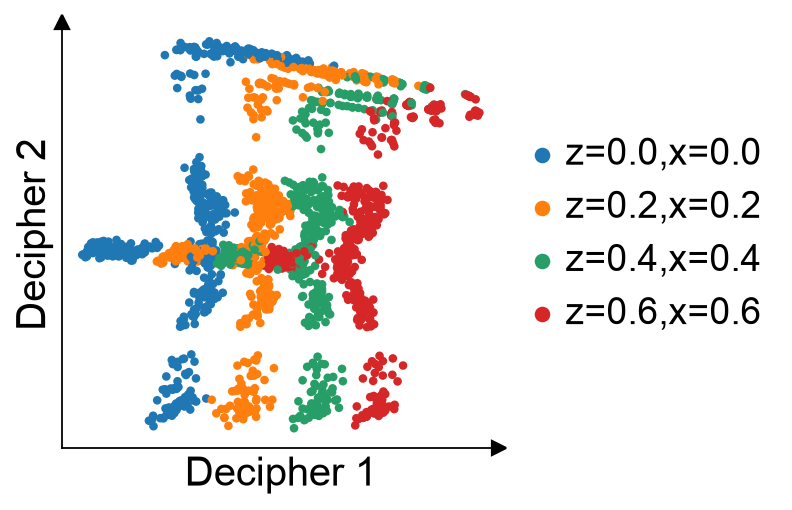

In [7]:
from decipher.tools._decipher import DecipherConfig
decipher_config = DecipherConfig(learning_rate=1e-3, seed=1)

adata_native = adata.copy()
d_native, val_native = dc.tl.decipher_train(
    adata_native, decipher_config, plot_kwargs={"color": "shift"},
    plot_every_k_epochs=5,
)

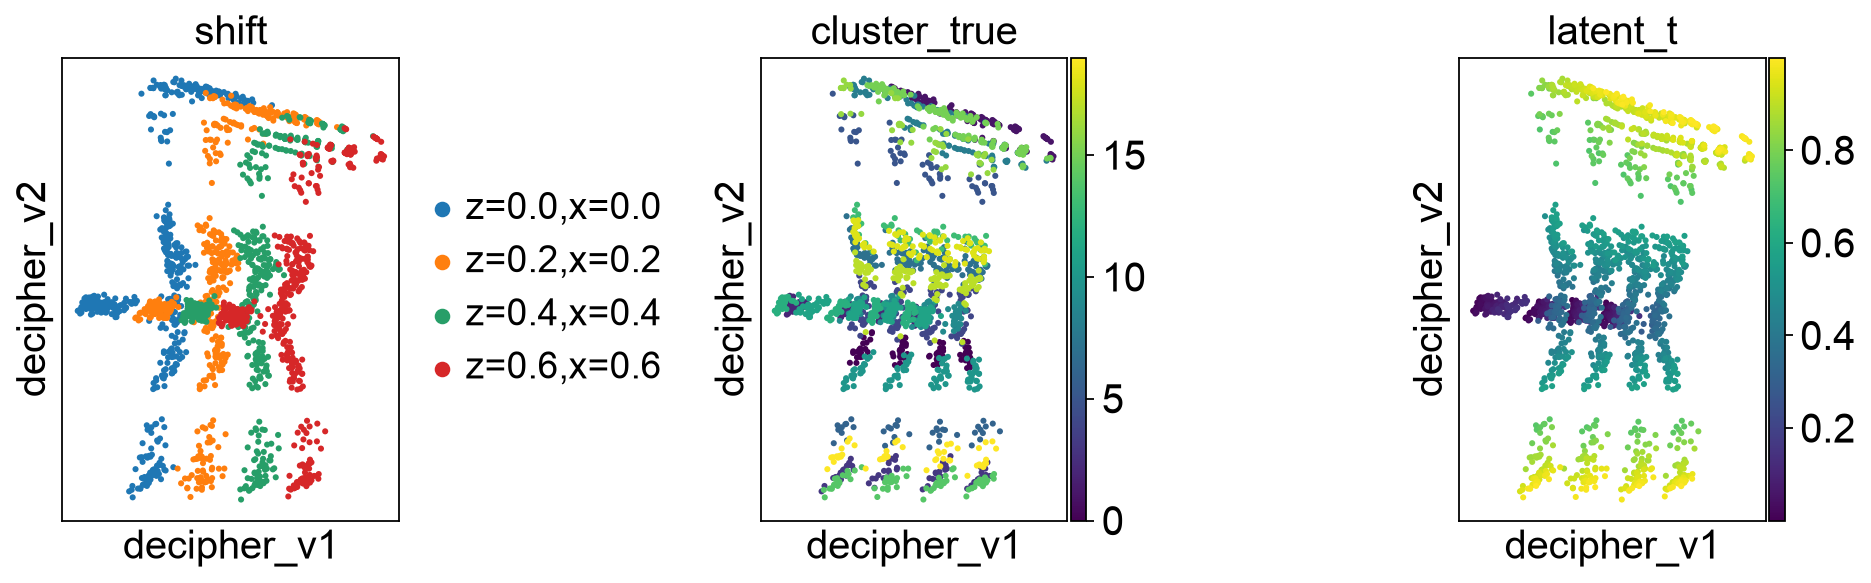

In [8]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import silhouette_samples

decipher_z = adata_native.obsm["decipher_z"]
k_means = KMeans(20)
k_means.fit(decipher_z)
adata_native.obs["cluster_latent"] = k_means.labels_

aris = {}
for a in adata_native.obs["shift"].unique():
    mask = adata_native.obs["shift"] == a
    aris[a] = adjusted_rand_score(
        adata_native.obs["cluster_true"][mask],
        adata_native.obs["cluster_latent"][mask],
    )

shift_labels = adata_native.obs["shift"]

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(4*3, 4))
sc.pl.embedding(adata_native, basis="decipher_v", color="shift",
                show=False, ax=axes[0], size=30)
sc.pl.embedding(adata_native, basis="decipher_v", color="cluster_true",
                show=False, ax=axes[1], size=30)
sc.pl.embedding(adata_native, basis="decipher_v", color="latent_t",
                show=False, ax=axes[2], size=30)
plt.tight_layout()
plt.show()

In [10]:
from sklearn.metrics import silhouette_score

v = adata_native.obsm["decipher_v"].copy()

covariates_to_score = {
    "shift": adata_native.obs["shift"].astype(str),
}

print("\n── Silhouette scores in v-space (higher = stronger separation) ──────────")
silhouette_results = {}
for name, labels in covariates_to_score.items():
    mask = labels != "nan"
    if labels[mask].nunique() < 2:
        print(f"  {name:<20} skipped (< 2 unique values)")
        continue
    score = silhouette_score(v[mask], labels[mask], sample_size=5000, random_state=42)
    silhouette_results[name] = score
    print(f"  {name:<25} silhouette = {score:.4f}")

SyntaxError: unterminated string literal (detected at line 9) (1142586800.py, line 9)

## Run concat-v-to-z on simulated data

## Run attention-v-z-x on simulated data

Epoch 190 (batch 20/20) | | train elbo: 99.59 (last epoch: 99.97) | val ll: 112.08:  19%|█▉        | 190/1000 [00:33<02:21,  5.71it/s]2026-06-15 16:18:26,647 | INFO : Early stopping has been triggered.
2026-06-15 16:18:26,648 | INFO : Added `.obsm['decipher_v']`: the Decipher v space.
2026-06-15 16:18:26,648 | INFO : Added `.obsm['decipher_z']`: the Decipher z space.
2026-06-15 16:18:26,652 | INFO : Saving decipher model with run_id 2026-06-15-16-18-26-toasted-feldspar-path.


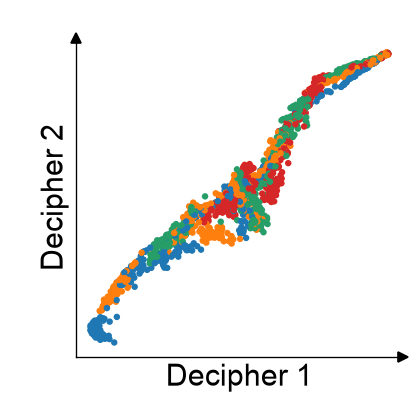

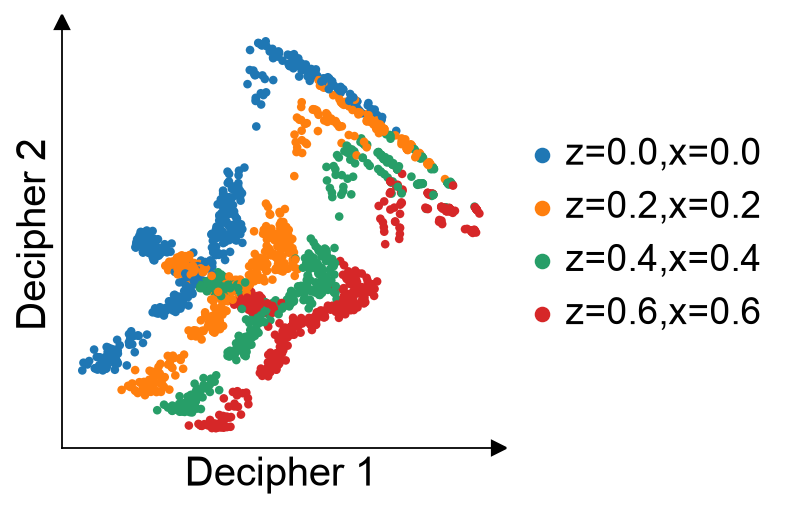

In [ ]:
from decipher.tools._decipher import DecipherConfig
decipher_config = DecipherConfig(learning_rate=1e-3, seed=1)

adata_avzx = adata.copy()
d_avzx, val_avzx = avzx.tl.decipher_train(
    adata_avzx, decipher_config, plot_kwargs={"color": "shift"},
    batch_key="shift",
    plot_every_k_epochs=5,
)

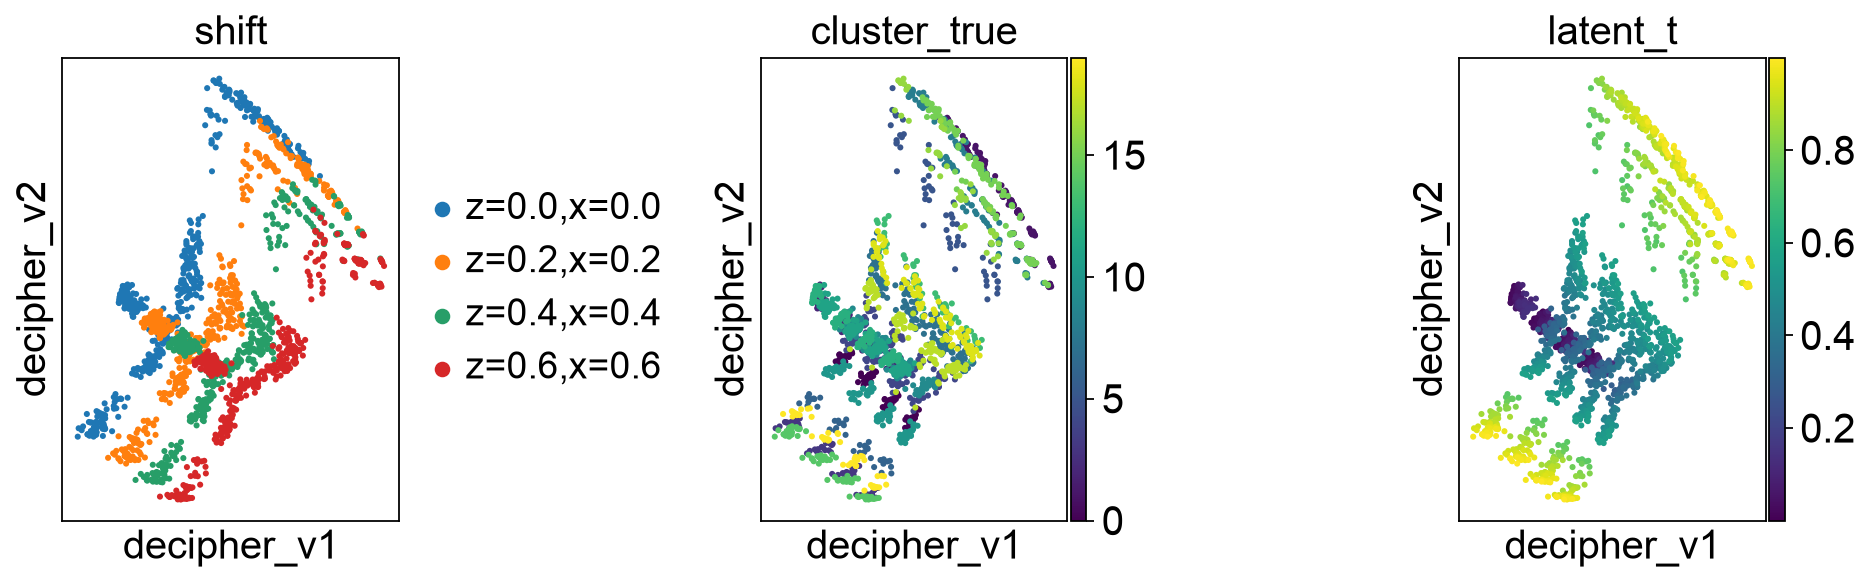

In [ ]:
from sklearn.cluster import KMeans
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from scipy.sparse.csgraph import minimum_spanning_tree
from sklearn.metrics import silhouette_samples

decipher_z = adata_avzx.obsm["decipher_z"]
k_means = KMeans(20)
k_means.fit(decipher_z)
adata_avzx.obs["cluster_latent"] = k_means.labels_

aris = {}
for a in adata_avzx.obs["shift"].unique():
    mask = adata_avzx.obs["shift"] == a
    aris[a] = adjusted_rand_score(
        adata_avzx.obs["cluster_true"][mask],
        adata_avzx.obs["cluster_latent"][mask],
    )
#print(f"[{suffix}] aris values: {aris}")

shift_labels = adata_avzx.obs["shift"]
# sil_values = silhouette_samples(decipher_z, shift_labels)
# df = pd.DataFrame({"silhouette_value": sil_values, "alpha": shift_labels.values})
# print(df.groupby("alpha", observed=True)["silhouette_value"].mean())

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(4*3, 4))
# sc.pl.embedding(adata_avzx, basis="decipher_v", color="shift",
#                 show=False, ax=axes[0], size=30)
sc.pl.embedding(adata_avzx, basis="decipher_v", color="shift",
                show=False, ax=axes[0], size=30)
sc.pl.embedding(adata_avzx, basis="decipher_v", color="cluster_true",
                show=False, ax=axes[1], size=30)
sc.pl.embedding(adata_avzx, basis="decipher_v", color="latent_t",
                show=False, ax=axes[2], size=30)
plt.tight_layout()
plt.show()

In [ ]:
# Plot decipher_z space — this is where attention-v-z-x applies batch correction.
# Compare to decipher_v above: shift groups should be less separated here if the model is working.
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(4*3, 4))
sc.pl.embedding(adata_avzx, basis="decipher_z", color="shift",
                show=False, ax=axes[0], size=30)
sc.pl.embedding(adata_avzx, basis="decipher_z", color="cluster_true",
                show=False, ax=axes[1], size=30)
sc.pl.embedding(adata_avzx, basis="decipher_z", color="latent_t",
                show=False, ax=axes[2], size=30)
plt.tight_layout()
plt.show()

In [ ]:
# Before choosing what to correct for, measure which covariates actually drive
# separation in the v-space. High silhouette = strong separation = bigger effect.

from sklearn.metrics import silhouette_score

v = adata_avzx.obsm['decipher_v'].copy()

# Only score covariates with at least 2 unique values and no NaNs
covariates_to_score = {
    "shift"   : adata_avzx.obs["shift"].astype(str),
}

print("\n── Silhouette scores in v-space (higher = stronger separation) ──────────")
silhouette_results = {}
for name, labels in covariates_to_score.items():
    # Drop NaN rows
    mask = labels != "nan"
    if labels[mask].nunique() < 2:
        print(f"  {name:<20} skipped (< 2 unique values)")
        continue
    score = silhouette_score(v[mask], labels[mask], sample_size=5000, random_state=42)
    silhouette_results[name] = score
    print(f"  {name:<25} silhouette = {score:.4f}")  



── Silhouette scores in v-space (higher = stronger separation) ──────────
  shift                     silhouette = 0.0098
